# 들어가는 말

참고문헌: L. Parker and S. M. Christensen, *MathTensor: A System for Doing Tensor Analysis by Computer* (Addison-Wesley, 1994)

`mTensor`는 `MathTensor`를 모델로 개발되었다. 따라서 기능상의 많은 차이에도 불구하고 두 시스템의 인터페이스는 매우 비슷하다. 사실 `mTensor`를 개발한 동기는 `Mathematica` 버전 3.0 이후부터 상하 첨자를 갖는 텐서를 제대로 표기할 수 있게 되었음에도 더 이상 업데이트하지 않는 `MathTensor`를 대치할 목적이었다. 이 노트북에서는 참고문헌 1장에 있는 `MathTensor` 명령을 유사한 역할을 하는 `mTensor` 명령으로 대치하였다.

# Chapter 1. A Brief Look at `MathTensor`

In [1]:
<< mTensor`

## 1.1 Creating Tensors with Symmetries

랭크가 2인 대칭 텐서 `s`를 정의한다:

In [3]:
Tdefine[s, "ba"]

인덱스 대칭을 이용하여 인덱스를 재조정할 수 있다. 인덱스 이름 앞의 'l' 문자는 covariant(lower) 인덱스를 의미한다.

In [4]:
s[la, lb] + s[lb, la]

s[la, lb] + s[lb, la]

In [5]:
% // TindexSort

2 s[la, lb]

인덱스 이름 앞의 'u' 문자는 contravariant(upper) 인덱스를 의미한다.

In [6]:
s[la, ua]

s[la, ua]

전자기장을 다루기 위해 반대칭 텐서 $F_{ab}$를 정의할 수 있다:

In [7]:
Tdefine[MaxwellF, "F", "-ba"]

리만 텐서 $R_{abc}^{\ \ \ \ \ d}$는 미리 정의되어 있다:

In [8]:
{MaxwellF[lb, la], RiemannCD[uc, ud, lb, la]}

{MaxwellF[lb, la], RiemannCD[uc, ud, lb, la]}

In [9]:
% // TindexSort

{-MaxwellF[la, lb], -RiemannCD[la, lb, uc, ud]}

## 1.2 Simplification

리치 텐서는 대칭 텐서이다.

In [10]:
RicciCD[la, uc] RicciCD[lc, lb] + RicciCD[le, la] RicciCD[lb, ue]

RicciCD[la, uc] RicciCD[lc, lb] + RicciCD[lb, ue] RicciCD[le, la]

단순화(simplification) 명령인 `Tsimplify`로 위의 표현을 단순화할 수 있다:

In [11]:
% // Tsimplify

2 RicciCD[la, lc] RicciCD[lb, uc]

MaxwellF는 반대칭 텐서이다.

In [12]:
(RicciCD[la, lb] + MaxwellF[la, lb])  * (RicciCD[ua, ub] + MaxwellF[ua, ub])

MaxwellF[la, lb] MaxwellF[ua, ub] + MaxwellF[ua, ub] RicciCD[la, lb] + 
 
>   MaxwellF[la, lb] RicciCD[ua, ub] + RicciCD[la, lb] RicciCD[ua, ub]

In [13]:
% // Tsimplify

MaxwellF[la, lb] MaxwellF[ua, ub] + RicciCD[la, lb] RicciCD[ua, ub]

리만 텐서의 대칭:
$$
  R_{abcd} = -R_{bacd} = -R_{abdc} = R_{cdab}
$$

In [14]:
GetSymmetry[RiemannCD]  (* signed permutations *)

GenSet[{Cycles[{{1, 2}}], -1}, {Cycles[{{3, 4}}], -1}, {Cycles[{{1, 3}, {2, 4}}], 1}]

In [15]:
% // GStoString

-bacd-abdc+cdab

In [16]:
% // AllPermutations  (* all possible permutations *)

+abcd-abdc-bacd+badc+cdab-cdba-dcab+dcba

In [17]:
RiemannCD[la, lb, ld, le] RicciCD[ua, ue] + 
 RiemannCD[lb, le, lc, ld] RicciCD[ue, uc]

RicciCD[ua, ue] RiemannCD[la, lb, ld, le] + RicciCD[ue, uc] RiemannCD[lb, le, lc, ld]

In [18]:
% // Tsimplify

-2 RicciCD[la, lc] RiemannCD[lb, ua, ld, uc]

## 1.3 Derivatives

전자기장 $F^{ab}$에 공변 도함수 $\nabla_a$와 $\nabla_b$가 적용되었다:

In [31]:
CD[la, lb, MaxwellF[ua, ub]]

CD[la, CD[lb, MaxwellF[ua, ub]]]

공변 도함수 $\nabla_a$를 보통 도함수 $\partial_a$로 바꾸려면 `CDtoGamma` 명령을 사용한다:

In [32]:
% // CDtoGamma

BD[la, CD[lb, MaxwellF[ua, ub]]] + CD[lb, MaxwellF[uc, ub]] GammaCD[la, lc, ua]

In [33]:
% // CDtoGamma

BD[la, BD[lb, MaxwellF[ua, ub]]] + BD[lb, MaxwellF[uc, ub]] GammaCD[la, lc, ua] + 
 
>   BD[la, MaxwellF[uc, ub]] GammaCD[lb, lc, ua] + 
 
>   BD[la, MaxwellF[ua, uc]] GammaCD[lb, lc, ub] + 
 
>   BD[la, GammaCD[lb, lc, ub]] MaxwellF[ua, uc] + 
 
>   BD[la, GammaCD[lb, lc, ua]] MaxwellF[uc, ub] + 
 
>   GammaCD[la, lc, ua] GammaCD[lb, ld, ub] MaxwellF[uc, ud] + 
 
>   GammaCD[la, lc, ua] GammaCD[lb, ld, uc] MaxwellF[ud, ub]

크리스토플 심볼 $\Gamma_{ab}^{\ \ \ c}$의 대칭:
$$
  \Gamma_{ab}^{\ \ \ c} = +\Gamma_{ba}^{\ \ \ c}
$$

In [34]:
GetSymmetry[GammaCD] // GStoString // AllPermutations

+ab+ba

텐서 인덱스들의 대칭을 이용하여 단순화한다:

In [35]:
%% // Tsimplify

-(BD[la, GammaCD[lb, lc, uc]] MaxwellF[ub, ua])

크리스토플 심볼 $\Gamma_{ab}^{\ \ \ c}$를 메트릭 텐서로 바꾼다:
$$
  \Gamma_{ab}^{\ \ \ c} = \frac{1}{2} g^{cd} (\partial_a g_{bd}
  + \partial_b g_{ad} - \partial_d g_{ab})
$$

-(BD[la, Metricg[uc, ud]] BD[lb, Metricg[lc, ld]] MaxwellF[ub, ua])
------------------------------------------------------------------- - 
                                 2
 
    BD[la, Metricg[uc, ud]] BD[lc, Metricg[lb, ld]] MaxwellF[ub, ua]
>   ---------------------------------------------------------------- + 
                                   2
 
    BD[la, Metricg[uc, ud]] BD[ld, Metricg[lb, lc]] MaxwellF[ub, ua]
>   ---------------------------------------------------------------- - 
                                   2
 
    BD[la, BD[lb, Metricg[lc, ld]]] MaxwellF[ub, ua] Metricg[uc, ud]
>   ---------------------------------------------------------------- - 
                                   2
 
    BD[la, BD[lc, Metricg[lb, ld]]] MaxwellF[ub, ua] Metricg[uc, ud]
>   ---------------------------------------------------------------- + 
                                   2
 
    BD[la, BD[ld, Metricg[lb, lc]]] MaxwellF[ub, ua] Metricg[uc, ud]
>   ----------------------------------------------------------------
                                   2
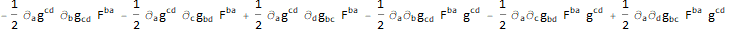

In [36]:
% // GammaToMetric

-(BD[la, Metricg[lb, lc]] BD[ld, Metricg[uc, ub]] MaxwellF[ua, ud])
-------------------------------------------------------------------
                                 2
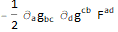

In [37]:
% // Tsimplify

단순화를 위하여 규칙 `BDinvgRule[]`를 적용한다:
$$
  \partial_a g^{bc} \rightarrow -g^{bd} g^{ce} \partial_a g_{de}
$$

(BD[la, Metricg[lb, lc]] BD[ld, Metricg[le, lf]] MaxwellF[ua, ud] Metricg[ub, uf] 
 
>     Metricg[uc, ue]) / 2
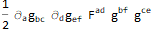

In [38]:
% /. BDinvgRule[]

In [39]:
% // Tsimplify

0

따라서 $\nabla_a \nabla_b F^{ab} = 0$이 증명되었다.

## 1.4 Differential Forms

2-form $f$를 정의한다:

In [40]:
Fdefine[f, 2]

시공간을 4차원으로 설정한다:

In [41]:
SetDimension[4]

외적(Exterior Product):

In [42]:
xpf = XP[f, f]

XP[f, f]

미분 형식(Differential Form)을 IndexedTensor로 바꾼다:

In [43]:
ToTensor[%, {la, lb, lc, ld}]

2 f[la, ld] f[lb, lc] - 2 f[la, lc] f[lb, ld] + 2 f[la, lb] f[lc, ld]

외미분(Exterior Derivative): 4차원에서 5-form은 0이다.

In [26]:
XD[xpf]

0

2-form의 외미분은 3-form이다.

In [44]:
XD[f]

XD[f[]]

In [45]:
ToTensor[%, {la, lb, lc}]

CD[la, f[lb, lc]] - CD[lb, f[la, lc]] + CD[lc, f[la, lb]]

Codifferential:

In [46]:
CoXD[f]

CoXD[f]

In [47]:
ToTensor[%, {la}]

-CD[ub, f[lb, la]]

## 1.5 Calculating Curvature

3차원 공간의 메트릭:
$$
  ds^2 = b^2 \left[
  \frac{dr^2}{1 - r^2} + r^2 d\theta^2
  + r^2 \sin^2 \theta d\phi^2 \right]
$$

In [48]:
coSys = {r, \[Theta], \[Phi]}

{r, θ, ϕ}

2
    b                 2  2              2  2       2
{{------, 0, 0}, {0, b  r , 0}, {0, 0, b  r  Sin[θ] }}
       2
  1 - r
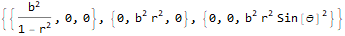

In [49]:
metric = b^2 {{1/(1 - r^2), 0, 0},
              {0, r^2, 0},
              {0, 0, r^2 Sin[\[Theta]]^2}}

2
  2    2   dr       2    2     2       2
ds  = b  (------ + r  (dθ  + dϕ  Sin[θ] ))
               2
          1 - r
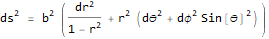

In [50]:
LineElement[coSys, metric, Simplify]

좌표계와 메트릭 표현을 입력으로 받아 여러 가지 (메트릭 텐서, 크리스토플 심볼, 리만 텐서, 리치 텐서 등)의 성분 연산을 한다:

In [51]:
InitCTensor[coSys, metric, RicciCD -> True]

메트릭 텐서 $g_{ab}$의 성분 표현:

2
   b      2  2   2  2       2
{------, b  r , b  r  Sin[θ] }
      2
 1 - r
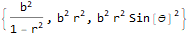

In [52]:
Table[Metricg[-i, -i], {i, 3}]

리치 텐서 $R_{ab}$의 성분 표현:

-2        2     2       2
{-------, 2 r , 2 r  Sin[θ] }
       2
 -1 + r
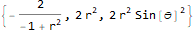

In [53]:
Table[RicciCD[-i, -i], {i, 3}] // Simplify

리만 텐서의 성분 $R_{1 \ \ 1}^{\ \ 3 \ \ 3}$과 $R_{2 \ \ 2}^{\ \ 3 \ \ 3}$:

2             2
       Csc[θ]        Csc[θ]
{-(---------------), -------}
    2  2        2       2
   b  r  (-1 + r )     b
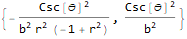

In [57]:
Table[SumDum[
   Metricg[3, uc] Metricg[3, ud] RiemannCD[-i, lc, -i, ld]],
   {i, 2}] // Simplify

스칼라 곡률 $R$:

In [58]:
ScalarCD[] // Simplify

6
--
 2
b

## 1.6 Calculating Invariants

1.5절의 메트릭으로부터 계산된 곡률 텐서의 불변량 $R_{ab} R^{ab}$을 계산한다:

In [60]:
RicciCD[la, lb] RicciCD[lc, ld] Metricg[uc, ua] Metricg[ud, ub]

Metricg[uc, ua] Metricg[ud, ub] RicciCD[la, lb] RicciCD[lc, ld]

Contracted 인덱스의 성분 합을 구한다(Einstein Summation):

In [61]:
% // SumDum // Simplify

12
--
 4
b

불변량 $R_{abcd} R^{abcd}$를 계산한다:

In [62]:
RiemannCD[la, lb, lc, ld] RiemannCD[le, lf, lg, lh]

RiemannCD[la, lb, lc, ld] RiemannCD[le, lf, lg, lh]

In [63]:
% Metricg[ue, ua] Metricg[uf, ub] Metricg[ug, uc] Metricg[uh, ud]

Metricg[ue, ua] Metricg[uf, ub] Metricg[ug, uc] Metricg[uh, ud] 
 
>   RiemannCD[la, lb, lc, ld] RiemannCD[le, lf, lg, lh]

In [64]:
% // SumDum // Simplify

12
--
 4
b

불변량 $R^{ac} R^{bd} R_{abcd}$를 계산한다:

In [65]:
RiemannCD[la, lb, lc, ld] RicciCD[le, lf] RicciCD[lg, lh]

RicciCD[le, lf] RicciCD[lg, lh] RiemannCD[la, lb, lc, ld]

In [66]:
% Metricg[ua, ue] Metricg[uc, uf] Metricg[ub, ug] Metricg[ud, uh]

Metricg[ua, ue] Metricg[ub, ug] Metricg[uc, uf] Metricg[ud, uh] RicciCD[le, lf] 
 
>   RicciCD[lg, lh] RiemannCD[la, lb, lc, ld]

In [67]:
% // SumDum // Simplify

24
--
 6
b

## 1.7 Multiple Types of Indices

`mTensor`에서 기본적으로 사용되는 인덱스는 Latin 계열('a', 'b', 'c', ...)의 문자이다.

In [69]:
Alphabet[]

{a, b, c, d, e, f, g, h, i, j, k, l, m, n, o, p, q, r, s, t, u, v, w, x, y, z}

여기에 더해서 새로운 계열의 인덱스를 도입할 수 있다. 이름이 'da', 'db', 'dc', ...인 Dot 계열의 인덱스를 도입하자:

In [75]:
"d" <> # & /@ Alphabet[]

{da, db, dc, dd, de, df, dg, dh, di, dj, dk, dl, dm, dn, do, dp, dq, dr, ds, dt, du, dv, 
 
>   dw, dx, dy, dz}

In [76]:
DefineKind[%, Dot]

벡터 $u$와 $v$를 정의한다:

In [77]:
Tdefine[{u, v}, 1]; {v[ua], v[uda]}

{v[ua], v[uda]}

두 벡터의 내적이다:

In [78]:
dotProduct = u[la] v[ua]

u[la] v[ua]

인덱스 $\dot{a}$는 부분 공간에 대한 것이고, 전체 공간에 대한 인덱스 $a$가 $\dot{a}$부터 3까지의 범위를 갖는다고 할 때 contracted 인덱스의 성분 합을 구한다:

In [79]:
SumDum[{la, lda, -3}, dotProduct]

u[-3] v[3] + u[lda] v[uda]

이름이 'rot'이고 $\omega$로 출력하는 텐서를 정의한다:

In [80]:
Tdefine[rot, "\[Omega]", 2]

In [81]:
expr = rot[la, ub] rot[lc, lb]

rot[la, ub] rot[lc, lb]

Contracted 인덱스의 성분 합을 구한다:

In [82]:
SumDum[{lb, ldb, -3}, expr]

rot[la, 3] rot[lc, -3] + rot[la, udb] rot[lc, ldb]

## 1.8 Rules with Dummy Indices

In [83]:
Tdefine[rot, "\[Omega]", 2]

인덱스 $a$와 $c$가 contracted 인덱스일 때 성립하는 규칙을 생성한다:

In [90]:
rotRule = rot[a_, b_] rot[c_, d_] /; PairIndexQ[b, d] :> Kdelta[a, c]

rot[a_, b_] rot[c_, d_] /; PairIndexQ[b, d] :> Kdelta[a, c]

In [91]:
rot[la, lc] rot[ub, uc]

rot[la, lc] rot[ub, uc]

규칙을 적용한다:

In [92]:
% /. rotRule

Kdelta[la, ub]

스칼라를 정의한다:

In [93]:
Tdefine[s[]]

더미 인덱스를 고려한 규칙을 생성한다:

In [94]:
sRule := RuleUnique[s[], rot[la, ua]]; sRule

s[] :> DumFresh[rot[l$63, u$63]]

In [95]:
s[]^3 /. sRule

3
rot[l$65, u$65]

In [96]:
% // FullForm

Power[rot["l$65", "u$65"], 3]

내부 표현에는 문제가 없지만 Mathematica 출력이 텐서 표현에 어울리지 않는다. 스칼라 표현을 `Tscalar`로 둘러 싼다:

In [100]:
Tscalar[s[]]^3 /. sRule

3
Tscalar[rot[l$71, u$71]]

## 1.9 Coordinate Transformations

좌표 변환 전과 후의 좌표계를 설정한다:

In [107]:
coSys = {x, y, z}; newCoSys = {x + K y, y, z};

각각의 좌표계에 대한 텐서를 정의한다:

In [108]:
Tdefine[{oldT, newT}, 2]

새로운 좌표계의 텐서 성분 $newT_{ab}$를 입력한다:

In [109]:
SetComponents[newT[la, lb], {{1, 0, 0}, {0, 1, 0}, {0, 0, 1}}]

좌표 변환 전의 텐서 성분 $oldT_{ab}$를 구한다:

In [110]:
Ttransform[oldT, newT[la, lb], coSys, newCoSys]

1        K        0

              2
K        1 + K    0


0        0        1
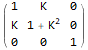

In [111]:
Table[oldT[-i, -j], {i, 3}, {j, 3}] // MatrixForm